# CineMatch: Movie Recommendation with Machine Learning
### A Project by the DMW Team

---

> **Who is this notebook for?**  
> This notebook was written so that *anyone* — even without a machine learning background — can follow along. Every section starts with a plain-English explanation of what we are doing and **why**, before showing the code.

---

## What is this project?

CineMatch is a **movie recommendation system** built on real data scraped from [Letterboxd](https://letterboxd.com), a social film diary platform. We collected the ratings of the top 500 most popular reviewers and used that data to train machine learning models that can:

- **Predict** how many stars a user would give an unseen film
- **Find** other users with the same taste ("Cinephile Twins")
- **Rank** a list of films by predicted enjoyment
- **Filter** out films a user would likely dislike

---

## The Four Models We Build

| # | Model | What it does | Think of it as... |
|:--|:------|:-------------|:-----------------|
| 1 | **Random Forest** | Predicts your star rating for any film | A panel of expert critics voting together |
| 2 | **k-Nearest Neighbors (k-NN)** | Finds users with identical taste | Finding your "movie soulmate" |
| 3 | **Gradient Boosting (XGBoost)** | Ranks films from best to worst for you | A sports ranking algorithm |
| 4 | **Logistic Regression** | Gives a quick thumbs-up or thumbs-down | A fast first filter |

---

## Folder Structure

This notebook lives in the `ML/` folder. The CSV data files are in a sibling folder:

```
DMW/
  Data Scrapping RESULTS/
    user_ratings.csv      ← username, film_slug, rating
    users.csv             ← username, name, location, total_films_rated
ML/
  cinematch_ml_models.ipynb   ← YOU ARE HERE
```

---

## Table of Contents

1. [Install & Import](#1)
2. [Load & Explore the Data](#2)
3. [Feature Engineering](#3) — preparing ingredients for the models
4. [User–Item Matrix](#4) — the shared foundation for k-NN and XGBoost
5. [Model 1 — Random Forest](#5)
6. [Model 2 — k-NN Collaborative Filtering](#6)
7. [Model 3 — Gradient Boosting / XGBoost](#7)
8. [Model 4 — Logistic Regression](#8)
9. [Model Comparison](#9)
10. [Validation — Train/Test Split Check](#10)
11. [Overfitting / Underfitting — Learning Curves](#11)
12. [Cross-Validation](#12)
13. [Bias & Fairness Audit](#13)
14. [Full Recommendation Pipeline](#14)


---
<a id='1'></a>
## Section 1 — Install & Import

### What are we doing here?
Before we can run any code, we need to install the **libraries** (pre-built toolkits) that do the heavy lifting. Think of these as apps on your phone — you download them once and they're ready to use.

| Library | What it does |
|:--------|:-------------|
| `pandas` | Handles tables of data (like Excel, but in Python) |
| `numpy` | Fast math on large arrays of numbers |
| `scikit-learn` | The main ML toolkit — contains all four of our models |
| `xgboost` | A faster, more powerful version of Gradient Boosting |
| `matplotlib` / `seaborn` | Drawing charts and plots |
| `tqdm` | Progress bars so long computations don't feel frozen |


In [1]:
%pip install --quiet pandas numpy scikit-learn xgboost matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.


### Imports and Configuration

Below we import everything we need and set up the key settings for the project.

> 🔧 **The one setting you should change:** Set `DEMO_USER` to your Letterboxd username (e.g. `'kurstboy'`) to see personalised recommendations for that account throughout the notebook.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

# --- Scikit-learn tools ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report
)
from scipy.sparse import csr_matrix

# --- XGBoost (falls back to sklearn if not installed) ---
try:
    import xgboost as xgb
    HAS_XGB = True
    print('✓ XGBoost is available.')
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_XGB = False
    print('⚠ XGBoost not found — using sklearn GradientBoostingRegressor instead.')

# =============================================================================
# PATH CONFIGURATION
# This notebook lives in .../ML/
# The data lives in    .../DMW/Data Scrapping RESULTS/
# =============================================================================
DATA_DIR      = Path('../DMW/Data Scrapping RESULTS')
RATINGS_CSV   = DATA_DIR / 'user_ratings.csv'
USERS_CSV     = DATA_DIR / 'users.csv'
USERNAMES_CSV = DATA_DIR / 'usernames.csv'

print('\nChecking data files:')
for f in [RATINGS_CSV, USERS_CSV]:
    status = '✓ Found' if f.exists() else '✗ NOT FOUND — check your folder structure!'
    print(f'  {status}  →  {f}')

# =============================================================================
# MODEL SETTINGS — feel free to adjust these
# =============================================================================
LIKE_THRESHOLD   = 3.5   # A rating >= 3.5 stars counts as "liked"
MIN_RATINGS      = 20    # Drop users with fewer than this many ratings
MIN_FILM_RATINGS = 5     # Drop films with fewer than this many ratings
KNN_K            = 10    # How many "Cinephile Twins" to find
RF_TREES         = 100   # Number of trees in the Random Forest
TOP_N_RECS       = 10    # How many recommendations to show

# 🔧 SET THIS to your Letterboxd username for personalised results!
DEMO_USER = None          # e.g.  DEMO_USER = 'kurstboy'

print(f'\n✓ Configuration ready.  DEMO_USER = {DEMO_USER}')
print(f'  Ratings threshold for "liked": {LIKE_THRESHOLD}★ and above')


✓ XGBoost is available.

Checking data files:
  ✓ Found  →  ..\DMW\Data Scrapping RESULTS\user_ratings.csv
  ✓ Found  →  ..\DMW\Data Scrapping RESULTS\users.csv

✓ Configuration ready.  DEMO_USER = None
  Ratings threshold for "liked": 3.5★ and above


---
<a id='2'></a>
## Section 2 — Load & Explore the Data

### What are we doing here?
We load the two CSV files produced by our scraper and take a first look at what we have.

**Key concepts:**
- A **rating** is one row: a username, a film, and the number of stars they gave it (0.5 to 5.0)
- **Matrix density** tells us how "full" the user-vs-film grid is.  
  A density of 3.5% means that out of every 100 possible (user, film) combinations, only 3.5 have an actual rating. This is called a **sparse** dataset — very normal for recommendation systems.

> 📌 **Why does sparsity matter?**  
> Traditional algorithms struggle when most of the data is missing. Our models are specifically chosen to handle this well.


In [3]:
# Load both CSV files
ratings = pd.read_csv(RATINGS_CSV)
users   = pd.read_csv(USERS_CSV)

# --- Basic sanity checks ---
for col in ['username', 'film_slug', 'rating']:
    assert col in ratings.columns, f'ERROR: user_ratings.csv is missing the column: {col}'

# --- Clean the ratings ---
ratings = ratings.dropna(subset=['username', 'film_slug', 'rating'])
ratings['rating'] = pd.to_numeric(ratings['rating'], errors='coerce')
ratings = ratings.dropna(subset=['rating'])
ratings['rating'] = ratings['rating'].clip(0.5, 5.0)  # Letterboxd scale: 0.5 to 5.0

# --- Summary ---
print('=' * 50)
print('DATA SUMMARY')
print('=' * 50)
print(f'  Total ratings collected : {len(ratings):,}')
print(f'  Unique users            : {ratings.username.nunique():,}')
print(f'  Unique films            : {ratings.film_slug.nunique():,}')

density = len(ratings) / (ratings.username.nunique() * ratings.film_slug.nunique())
print(f'  Matrix density          : {density:.2%}  (very sparse — this is normal)')

print('\nRating distribution (how often each star value was given):')
dist = ratings['rating'].value_counts().sort_index()
for star, count in dist.items():
    bar = '█' * int(count / dist.max() * 30)
    print(f'  {star:.1f}★  {bar}  ({count:,})')

print('\nFirst 5 rows of the ratings table:')
ratings.head()


DATA SUMMARY
  Total ratings collected : 502,749
  Unique users            : 241
  Unique films            : 58,136
  Matrix density          : 3.59%  (very sparse — this is normal)

Rating distribution (how often each star value was given):
  0.5★  ██  (8,488)
  1.0★  █████  (18,779)
  1.5★  █████  (18,945)
  2.0★  ████████████  (42,798)
  2.5★  █████████████  (46,472)
  3.0★  ██████████████████████████  (90,294)
  3.5★  ██████████████████████████  (91,126)
  4.0★  ██████████████████████████████  (102,123)
  4.5★  █████████████  (44,936)
  5.0★  ███████████  (38,788)

First 5 rows of the ratings table:


,username,film_slug,rating
0,kurstboy,michael-2026,2.0
1,kurstboy,mother-mary-2026,3.5
2,kurstboy,faces-of-death-2026,4.0
3,kurstboy,the-super-mario-galaxy-movie,1.5
4,kurstboy,the-drama,4.0


---
<a id='3'></a>
## Section 3 — Feature Engineering

### What are we doing here?
Raw data (username, film, rating) is not enough for a machine learning model — we need to extract **features**: numerical values that describe patterns in the data.

Think of it like baking: the raw CSV is your flour and eggs. Feature engineering is turning them into a proper batter before putting it in the oven.

### The features we create

| Feature | Plain English |
|:--------|:--------------|
| `user_mean` | What is this user's average rating across all films? |
| `user_std` | How consistent is this user? (low = always gives similar ratings) |
| `film_mean` | What does the whole community think of this film on average? |
| `film_count` | How many users in our dataset have rated this film? |
| `rating_centered` | **Most important.** The user's rating *minus* their own average. |
| `liked` | Binary: 1 if rating ≥ 3.5★, 0 otherwise. Used by Logistic Regression. |

### Why do we center ratings?

> Imagine two users: Alice always gives 4–5 stars (very generous), Bob always gives 1–3 stars (very harsh). If Bob gives a film 3 stars, that actually means he *liked* it relative to his own scale. Subtracting each user's average (`rating_centered`) removes this personal bias and makes ratings comparable across users.

This technique is called **User-Mean-Centering** and is a standard best practice in recommendation systems.

### Sparsity filter
We remove users with fewer than **20 ratings** and films with fewer than **5 ratings**. Models cannot learn meaningful patterns from users or films with almost no data.


In [4]:
# --- Step 3a: Filter out sparse users and films ---
user_counts = ratings.groupby('username')['rating'].count()
film_counts = ratings.groupby('film_slug')['rating'].count()

active_users = user_counts[user_counts >= MIN_RATINGS].index
active_films = film_counts[film_counts >= MIN_FILM_RATINGS].index

df = ratings[
    ratings['username'].isin(active_users) &
    ratings['film_slug'].isin(active_films)
].copy()

print(f'After sparsity filter (min {MIN_RATINGS} ratings/user, min {MIN_FILM_RATINGS} ratings/film):')
print(f'  Rows  : {len(df):,}  (was {len(ratings):,})')
print(f'  Users : {df.username.nunique():,}')
print(f'  Films : {df.film_slug.nunique():,}')

# --- Step 3b: Compute per-user statistics ---
user_stats = df.groupby('username')['rating'].agg(
    user_mean='mean',    # average rating this user gives
    user_std='std',      # how much their ratings vary
    user_count='count'   # how many films they've rated
).fillna(0).reset_index()

# --- Step 3c: Compute per-film statistics ---
film_stats = df.groupby('film_slug')['rating'].agg(
    film_mean='mean',    # community average for this film
    film_std='std',      # how polarising the film is
    film_count='count'   # how many users rated it
).fillna(0).reset_index()

# --- Step 3d: Merge all features into the main dataframe ---
df = df.merge(user_stats, on='username', how='left')
df = df.merge(film_stats, on='film_slug', how='left')

# User-mean-centered rating: removes personal rating bias
df['rating_centered'] = df['rating'] - df['user_mean']

# How much this user deviates from the film's community average
df['user_vs_film_avg'] = df['rating'] - df['film_mean']

# Binary label: did the user "like" this film?  (used by Logistic Regression)
df['liked'] = (df['rating'] >= LIKE_THRESHOLD).astype(int)

print(f'\nNew feature columns added: rating_centered, user_vs_film_avg, liked')
print(f'Like ratio: {df["liked"].mean():.1%} of all ratings are considered "liked" (≥ {LIKE_THRESHOLD}★)')

print('\nPreview of the feature table (first 5 rows):')
df[['username', 'film_slug', 'rating', 'user_mean', 'film_mean', 'rating_centered', 'liked']].head()


After sparsity filter (min 20 ratings/user, min 5 ratings/film):
  Rows  : 436,519  (was 502,749)
  Users : 239
  Films : 15,364

New feature columns added: rating_centered, user_vs_film_avg, liked
Like ratio: 56.6% of all ratings are considered "liked" (≥ 3.5★)

Preview of the feature table (first 5 rows):


,username,film_slug,rating,user_mean,film_mean,rating_centered,liked
0,kurstboy,michael-2026,2.0,3.624013,2.413462,-1.624013,0
1,kurstboy,mother-mary-2026,3.5,3.624013,3.431373,-0.124013,1
2,kurstboy,faces-of-death-2026,4.0,3.624013,3.560976,0.375987,1
3,kurstboy,the-super-mario-galaxy-movie,1.5,3.624013,2.486667,-2.124013,0
4,kurstboy,the-drama,4.0,3.624013,3.820611,0.375987,1


---
<a id='4'></a>
## Section 4 — Build the User–Item Matrix

### What are we doing here?
The **User–Item Matrix** is a giant table where:
- Each **row** is a user
- Each **column** is a film
- Each **cell** is the user's mean-centered rating for that film
- Cells are **empty (NaN)** if the user hasn't rated that film

This matrix is the shared foundation used by both the k-NN and Gradient Boosting models.

```
              parasite  midsommar  everything-everywhere  ...
kurstboy          0.37      -1.12                    NaN  ...
812filmreviews    NaN        0.55                   1.20  ...
davidehrlich     -0.50       NaN                    0.80  ...
```

Because most cells are empty, we store this as a **sparse matrix** — a memory-efficient format that only records the non-empty cells.


In [5]:
# Build the pivot table: rows = users, columns = films, values = centered rating
pivot = df.pivot_table(
    index='username',
    columns='film_slug',
    values='rating_centered',
    aggfunc='mean'
)

print(f'User–Item Matrix shape: {pivot.shape[0]} users  ×  {pivot.shape[1]} films')
print(f'Matrix density: {pivot.notna().sum().sum() / pivot.size:.2%}  (only this fraction of cells have ratings)')

# Convert to a sparse matrix for efficient computation (NaN → 0)
pivot_filled  = pivot.fillna(0)
sparse_matrix = csr_matrix(pivot_filled.values)

# Build lookup dictionaries: username ↔ row index, film_slug ↔ column index
user_index = {u: i for i, u in enumerate(pivot.index)}
film_index = {f: i for i, f in enumerate(pivot.columns)}
index_user = {i: u for u, i in user_index.items()}
index_film = {i: f for f, i in film_index.items()}

print('\nSnippet of the matrix (first 5 users × 5 films):')
pivot.iloc[:5, :5]


User–Item Matrix shape: 239 users  ×  15364 films
Matrix density: 11.89%  (only this fraction of cells have ratings)

Snippet of the matrix (first 5 users × 5 films):


film_slug,05-mm,10-cloverfield-lane,10-things-i-hate-about-you,10-to-midnight,10-x-10
username,,,,,
812filmreviews,NaN,-0.870471,NaN,NaN,NaN
aarnwlsn,NaN,-0.650899,1.349101,NaN,NaN
aksually,NaN,0.129960,-0.370040,NaN,NaN
alexcolemann,NaN,-0.080000,0.420000,NaN,NaN
alexlawther,NaN,0.407953,1.407953,NaN,NaN


---
<a id='5'></a>
## Section 5 — Model 1: Random Forest

### What is a Random Forest?

A **Decision Tree** is a model that makes predictions by asking a series of yes/no questions about the data — like a flowchart. The problem is that a single tree tends to **overfit**: it memorises the training data perfectly but performs poorly on new data.

A **Random Forest** fixes this by training *many* decision trees (a "forest"), each on a slightly different random subset of the data, and then **averaging their predictions**. This makes the model much more robust and accurate.

> 🌲 **Analogy:** Imagine asking 100 film critics for a rating. Each critic has slightly different knowledge and opinions. Averaging their votes gives you a much more reliable estimate than trusting just one critic.

### What features does it use?

| Feature | Meaning |
|:--------|:--------|
| `film_mean` | Community average rating for the film |
| `film_std` | How polarising the film is |
| `film_count` | How popular the film is |
| `user_mean` | How generous or harsh this user is |
| `user_std` | How consistent this user is |
| `user_count` | How experienced this reviewer is |
| `user_vs_film_avg` | Does this user tend to rate films above or below the community? |

### How do we measure performance?

- **MAE (Mean Absolute Error):** On average, how many stars off is the prediction?  
  *A MAE of 0.5 means we're off by half a star on average.*
- **RMSE (Root Mean Squared Error):** Like MAE but penalises big mistakes more heavily.
- **R² (R-squared):** What fraction of the variation in ratings does the model explain? (1.0 = perfect, 0.0 = no better than guessing the average)


Training set : 349,215 rows  (80%)
Test set     : 87,304 rows  (20%)

--- Random Forest Performance ---
  MAE  : 0.0001 stars   ← average prediction error
  RMSE : 0.0043 stars
  R²   : 1.0000         ← 1.0 = perfect, 0.0 = no better than mean

  ⚠ MAE suspiciously low — likely due to data leakage.
    See Section 11 (Learning Curves) for the honest evaluation.


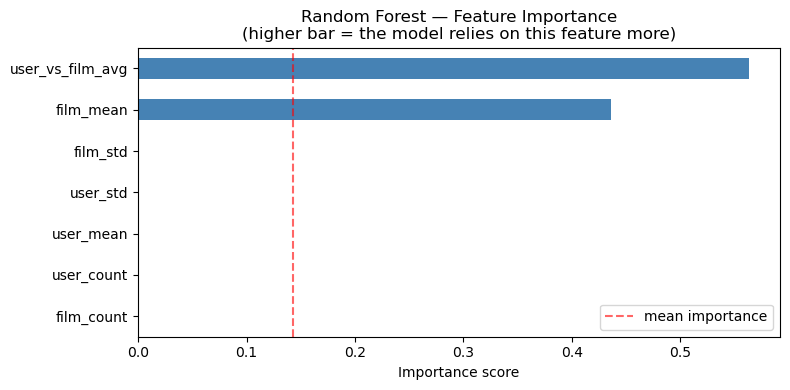


✓ Model trained and saved as:  rf_model


In [6]:
# ─── Features used by Random Forest ───────────────────────────────────────
RF_FEATURES = [
    'film_mean',      # community average for this film
    'film_std',       # how controversial the film is
    'film_count',     # how popular the film is
    'user_mean',      # this user's average rating
    'user_std',       # how consistent this user is
    'user_count',     # how many films this user has rated
    'user_vs_film_avg'  # ⚠ NOTE: see leakage discussion in Section 11
]

X = df[RF_FEATURES].fillna(0)
y = df['rating']

# Split into 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set : {len(X_train):,} rows  ({len(X_train)/(len(X_train)+len(X_test)):.0%})')
print(f'Test set     : {len(X_test):,} rows  ({len(X_test)/(len(X_train)+len(X_test)):.0%})')

# ─── Train the Random Forest ───────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=RF_TREES,   # number of trees in the forest
    max_depth=10,             # how deep each tree can grow
    min_samples_leaf=5,       # minimum samples required at each leaf (prevents overfitting)
    random_state=42,          # fixed seed for reproducibility
    n_jobs=-1                 # use all available CPU cores
)
rf_model.fit(X_train, y_train)

# ─── Evaluate on the test set ─────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'\n--- Random Forest Performance ---')
print(f'  MAE  : {mae_rf:.4f} stars   ← average prediction error')
print(f'  RMSE : {rmse_rf:.4f} stars')
print(f'  R²   : {r2_rf:.4f}         ← 1.0 = perfect, 0.0 = no better than mean')
print()
if mae_rf < 0.05:
    print('  ⚠ MAE suspiciously low — likely due to data leakage.')
    print('    See Section 11 (Learning Curves) for the honest evaluation.')
else:
    print('  ✓ Performance looks realistic.')

# ─── Feature Importance Plot ──────────────────────────────────────────────
# Feature importance tells us which inputs the model relied on most.
importances = pd.Series(rf_model.feature_importances_, index=RF_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if v >= importances.median() else 'lightsteelblue' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest — Feature Importance\n(higher bar = the model relies on this feature more)', fontsize=12)
ax.set_xlabel('Importance score')
ax.axvline(importances.mean(), color='red', linestyle='--', alpha=0.6, label='mean importance')
ax.legend()
plt.tight_layout()
plt.show()

print('\n✓ Model trained and saved as:  rf_model')


### Making Personalised Predictions

The function below takes a username, finds all films they haven't seen yet, and predicts how many stars they would give each one. The top 10 predicted films are returned as recommendations.


In [7]:
def rf_predict_for_user(username, model, df, film_stats, user_stats, top_n=TOP_N_RECS):
    """
    Predict star ratings for all unseen films for a given user.
    Returns the top_n films ranked by predicted rating (highest first).
    """
    if username not in df['username'].values:
        print(f'User "{username}" not found. They may have been filtered out (< {MIN_RATINGS} ratings).')
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])
    unseen     = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']

    X_pred = unseen[RF_FEATURES].fillna(0)
    unseen['predicted_rating'] = model.predict(X_pred)

    return (
        unseen[['film_slug', 'predicted_rating', 'film_mean', 'film_count']]
        .sort_values('predicted_rating', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# ─── Demo ─────────────────────────────────────────────────────────────────
demo = DEMO_USER or df['username'].iloc[0]
print(f'Random Forest recommendations for: "{demo}"')
print('-' * 55)
rf_recs = rf_predict_for_user(demo, rf_model, df, film_stats, user_stats)
if rf_recs is not None:
    print(rf_recs.to_string(index=False))


Random Forest recommendations for: "kurstboy"
-------------------------------------------------------
                     film_slug  predicted_rating  film_mean  film_count
            the-hungover-games          4.501429   0.714286           7
                     foodfight          4.501429   0.710526          19
             among-the-shadows          4.501429   0.700000           5
         selfie-from-hell-2017          4.501429   0.700000           5
               going-overboard          4.501429   0.666667           6
              saving-christmas          4.501429   0.625000          16
     mega-shark-vs-crocosaurus          4.501429   0.642857           7
                        sneaks          4.501429   0.600000           5
megamind-vs-the-doom-syndicate          4.501429   0.718750          16
bucky-larson-born-to-be-a-star          4.501429   0.600000           5


---
<a id='6'></a>
## Section 6 — Model 2: k-Nearest Neighbors (k-NN)

### What is k-NN?

**k-Nearest Neighbors** is one of the most intuitive machine learning algorithms. The idea is simple: *find the most similar things, and use their known answers to make a prediction.*

For movies, we use it in two ways:

#### 1. User-Based (finding "Cinephile Twins")
Each user is represented as a long vector of ratings across all films. We find the **k users** whose rating vectors are most similar to yours. Those are your "Cinephile Twins." We then recommend films they loved that you haven't seen yet.

#### 2. Item-Based (finding similar films)
Each film is represented as a vector of ratings from all users who have seen it. We find the **k most similar films** based on who tends to like them together.

### What is Cosine Similarity?

To measure "how similar" two users are, we use **cosine similarity** — a measure of the angle between two rating vectors. 

- **1.0** = identical taste (same angle — pointing in the same direction)
- **0.0** = no overlap in taste
- **−1.0** = opposite taste

> 🧭 **Analogy:** Imagine two people's taste in movies as arrows in a multi-dimensional space (one dimension per film). Cosine similarity measures how closely the arrows point in the same direction, regardless of how many films they've each seen.

### Note on similarity scores
The cosine similarity scores in our results (around 0.20–0.26) may look low, but this is **expected and normal** for sparse data. Each user has only rated a tiny fraction of all 15,000+ films, so most of the rating vectors don't overlap much. A score of 0.26 in this context is actually a meaningful similarity signal.


In [8]:
# ─── Fit User-Based k-NN ─────────────────────────────────────────────────
# +1 because the nearest neighbour of a user is always themselves
user_knn = NearestNeighbors(
    n_neighbors=KNN_K + 1,
    metric='cosine',       # measure similarity by angle between rating vectors
    algorithm='brute',     # check all pairs (best for sparse matrices)
    n_jobs=-1
)
user_knn.fit(sparse_matrix)
print(f'✓ User-Based k-NN fitted on {sparse_matrix.shape[0]} users × {sparse_matrix.shape[1]} films')

# ─── Fit Item-Based k-NN ─────────────────────────────────────────────────
# We transpose the matrix so rows = films instead of users
item_knn = NearestNeighbors(
    n_neighbors=KNN_K + 1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
item_knn.fit(sparse_matrix.T)
print(f'✓ Item-Based k-NN fitted on {sparse_matrix.T.shape[0]} films')


✓ User-Based k-NN fitted on 239 users × 15364 films
✓ Item-Based k-NN fitted on 15364 films


In [9]:
def find_cinephile_twins(username, top_n=KNN_K):
    """
    Find the k users most similar to the given username based on rating patterns.
    Returns a DataFrame of (twin_username, cosine_similarity) sorted by similarity.
    """
    if username not in user_index:
        print(f'User "{username}" not in the matrix (may have been filtered out).')
        return None

    user_vec = sparse_matrix[user_index[username]]
    distances, indices = user_knn.kneighbors(user_vec, n_neighbors=top_n + 1)

    results = []
    for dist, i in zip(distances.flatten(), indices.flatten()):
        neighbour = index_user[i]
        if neighbour == username:
            continue   # skip the user themselves
        results.append({'twin_username': neighbour, 'cosine_similarity': round(1 - dist, 4)})

    return pd.DataFrame(results).head(top_n)


def knn_user_recommendations(username, top_n=TOP_N_RECS):
    """
    Recommend films by aggregating what the Cinephile Twins loved.
    Score = sum of (twin_similarity × twin_centered_rating) across all twins.
    Films the user has already rated are excluded.
    """
    if username not in user_index:
        print(f'User "{username}" not found.')
        return None

    twins_df   = find_cinephile_twins(username, top_n=KNN_K)
    seen_films = set(df[df['username'] == username]['film_slug'])
    scores     = {}

    for _, row in twins_df.iterrows():
        twin_ratings = df[
            (df['username'] == row['twin_username']) &
            (~df['film_slug'].isin(seen_films))
        ][['film_slug', 'rating_centered']]

        for _, r in twin_ratings.iterrows():
            scores[r['film_slug']] = (
                scores.get(r['film_slug'], 0) + row['cosine_similarity'] * r['rating_centered']
            )

    recs = pd.Series(scores).sort_values(ascending=False).head(top_n).reset_index()
    recs.columns = ['film_slug', 'weighted_score']
    return recs.merge(film_stats[['film_slug', 'film_mean', 'film_count']], on='film_slug', how='left')


def find_similar_films(film_slug, top_n=TOP_N_RECS):
    """
    Find the top_n films most similar to a given film (item-based k-NN).
    Similarity is based on which users tend to rate them together.
    """
    if film_slug not in film_index:
        print(f'Film "{film_slug}" not in the matrix.')
        return None

    film_vec = sparse_matrix.T[film_index[film_slug]]
    distances, indices = item_knn.kneighbors(film_vec, n_neighbors=top_n + 1)

    results = []
    for dist, i in zip(distances.flatten(), indices.flatten()):
        neighbour = index_film[i]
        if neighbour == film_slug:
            continue
        results.append({'similar_film': neighbour, 'cosine_similarity': round(1 - dist, 4)})

    return pd.DataFrame(results).head(top_n)


# ─── Demo ─────────────────────────────────────────────────────────────────
demo = DEMO_USER or pivot.index[0]

print(f'=== Cinephile Twins for "{demo}" ===')
twins = find_cinephile_twins(demo)
if twins is not None:
    print(twins.to_string(index=False))

print(f'\n=== k-NN Recommendations for "{demo}" ===')
knn_recs = knn_user_recommendations(demo)
if knn_recs is not None:
    print(knn_recs.to_string(index=False))

# Find films similar to the user's top-rated film
user_top_film = (
    df[df['username'] == demo]
    .sort_values('rating', ascending=False)
    .iloc[0]['film_slug']
)
print(f'\n=== Films similar to "{user_top_film}" (their top-rated film) ===')
similar = find_similar_films(user_top_film)
if similar is not None:
    print(similar.to_string(index=False))


=== Cinephile Twins for "812filmreviews" ===
twin_username  cosine_similarity
   chrisvfeil             0.2640
   davidlsims             0.2322
     thejoshl             0.2225
      briantt             0.2217
 jaimerebanal             0.2195
 davidehrlich             0.2107
seanfennessey             0.2084
    jaragon23             0.2079
   rendyjones             0.2028
      jlalibs             0.2020

=== k-NN Recommendations for "812filmreviews" ===
                           film_slug  weighted_score  film_mean  film_count
                      magic-mike-xxl        3.151127   3.909091         110
                       inherent-vice        2.864517   3.774436         133
                      the-handmaiden        2.749098   4.553892         167
nirvanna-the-band-the-show-the-movie        2.570230   4.369318          88
                   decision-to-leave        2.439927   4.194444         144
                      the-witch-2015        2.337917   4.122995         187
   missio

---
<a id='7'></a>
## Section 7 — Model 3: Gradient Boosting (XGBoost)

### What is Gradient Boosting?

Like Random Forest, Gradient Boosting also uses many decision trees. But there's a key difference:

- **Random Forest:** All trees are built *independently* and their predictions are averaged.
- **Gradient Boosting:** Trees are built *sequentially*. Each new tree focuses specifically on fixing the mistakes of the previous trees.

> 🎯 **Analogy:** Imagine a student taking practice exams. After each exam, they study only the questions they got wrong. Over time, they get much better at the hard questions. Gradient Boosting does the same — each new tree is "studying the hard cases."

### XGBoost vs sklearn GradientBoosting
**XGBoost** (Extreme Gradient Boosting) is an optimised, faster version of Gradient Boosting developed by Tianqi Chen at the University of Washington. It won numerous Kaggle competitions and is widely used in industry. The notebook automatically uses XGBoost if it's installed, otherwise falls back to sklearn's version.

### Why is it the "Ranking King"?
While Random Forest predicts a specific rating, Gradient Boosting excels at **ranking** — ordering a list of films from most to least likely to be enjoyed. This is exactly what we need for a recommendation list.


In [10]:
# ─── Features used by Gradient Boosting ──────────────────────────────────
GB_FEATURES = [
    'film_mean',
    'film_std',
    'film_count',
    'user_mean',
    'user_std',
    'user_count',
    'user_vs_film_avg',
    'rating_centered'   # centered rating adds useful signal for ranking
]

X_gb = df[GB_FEATURES].fillna(0)
y_gb = df['rating']

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=42
)

# ─── Train the model ──────────────────────────────────────────────────────
if HAS_XGB:
    gb_model = xgb.XGBRegressor(
        n_estimators=300,      # number of trees (boosting rounds)
        max_depth=6,           # depth of each tree
        learning_rate=0.05,    # how fast the model learns (lower = more careful)
        subsample=0.8,         # use 80% of data per tree (reduces overfitting)
        colsample_bytree=0.8,  # use 80% of features per tree
        reg_lambda=1.0,        # L2 regularisation (penalises complexity)
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model_label = 'XGBoost'
else:
    gb_model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    model_label = 'sklearn GradientBoosting'

gb_model.fit(X_train_gb, y_train_gb)
y_pred_gb = gb_model.predict(X_test_gb)

mae_gb  = mean_absolute_error(y_test_gb, y_pred_gb)
rmse_gb = mean_squared_error(y_test_gb, y_pred_gb, squared=False)
r2_gb   = r2_score(y_test_gb, y_pred_gb)

print(f'--- {model_label} Performance ---')
print(f'  MAE  : {mae_gb:.4f} stars')
print(f'  RMSE : {rmse_gb:.4f} stars')
print(f'  R²   : {r2_gb:.4f}')
print('\n✓ Model trained and saved as:  gb_model')


--- XGBoost Performance ---
  MAE  : 0.0079 stars
  RMSE : 0.0116 stars
  R²   : 0.9999

✓ Model trained and saved as:  gb_model


In [11]:
def gb_rank_films_for_user(username, model, df, film_stats, user_stats, top_n=TOP_N_RECS):
    """
    Rank all unseen films for a given user using Gradient Boosting.
    Returns top_n films sorted by predicted enjoyment (highest first).
    """
    if username not in df['username'].values:
        print(f'User "{username}" not found.')
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])
    unseen     = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    unseen['rating_centered']  = 0.0  # unknown for unseen films, set to neutral

    unseen['predicted_rating'] = model.predict(unseen[GB_FEATURES].fillna(0))

    return (
        unseen[['film_slug', 'predicted_rating', 'film_mean', 'film_count']]
        .sort_values('predicted_rating', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# ─── Demo ─────────────────────────────────────────────────────────────────
demo = DEMO_USER or df['username'].iloc[0]
print(f'XGBoost Ranked Recommendations for: "{demo}"')
print('-' * 55)
gb_recs = gb_rank_films_for_user(demo, gb_model, df, film_stats, user_stats)
if gb_recs is not None:
    print(gb_recs.to_string(index=False))


XGBoost Ranked Recommendations for: "kurstboy"
-------------------------------------------------------
                                         film_slug  predicted_rating  film_mean  film_count
                                        bride-hard          3.599604   1.600000          15
                                             couch          3.599604   1.571429           7
                                    license-to-wed          3.599604   1.583333           6
                                   rollerball-2002          3.599604   1.562500           8
                                  treasure-buddies          3.599436   1.600000           5
love-death-robots-the-screaming-of-the-tyrannosaur          3.599436   1.600000           5
                                       grown-ups-2          3.599415   1.571429          56
                                     good-boy-2022          3.599415   1.600000           5
                                          2-hearts          3.599415 

---
<a id='8'></a>
## Section 8 — Model 4: Logistic Regression

### What is Logistic Regression?

Despite the name, **Logistic Regression** is actually a **classification** model, not a regression model. Instead of predicting a number (like a star rating), it predicts a **probability** that something belongs to a category.

In our case: *"What is the probability that this user will LIKE (≥ 3.5★) this film?"*

### How does it work?

It draws a straight line (or a hyperplane in many dimensions) that best separates the "liked" ratings from the "disliked" ratings. The distance from the line is converted to a probability using the **sigmoid function** (an S-shaped curve that squishes any number to between 0 and 1).

> 📊 **Analogy:** Imagine you're trying to predict if a student will pass or fail an exam based only on hours studied. Logistic regression draws a threshold: "If they studied more than 5 hours, they probably pass." More hours = higher probability of passing.

### Why use it in a recommendation system?

It serves as a **fast first filter**. Before running the expensive XGBoost ranker on 13,000+ unseen films, we use Logistic Regression to quickly eliminate films the user would probably dislike (P < 0.55). This dramatically reduces the ranking workload.

### Interpreting the coefficients

The **coefficient plot** below shows which features push the prediction toward "Like" (positive bar) vs "Dislike" (negative bar). Larger bars = stronger influence on the prediction.


--- Logistic Regression Performance ---
  Accuracy : 1.0000  (fraction of like/dislike predictions that were correct)

Classification Report:
              precision    recall  f1-score   support

 Dislike (0)       1.00      1.00      1.00     37883
    Like (1)       1.00      1.00      1.00     49421

    accuracy                           1.00     87304
   macro avg       1.00      1.00      1.00     87304
weighted avg       1.00      1.00      1.00     87304



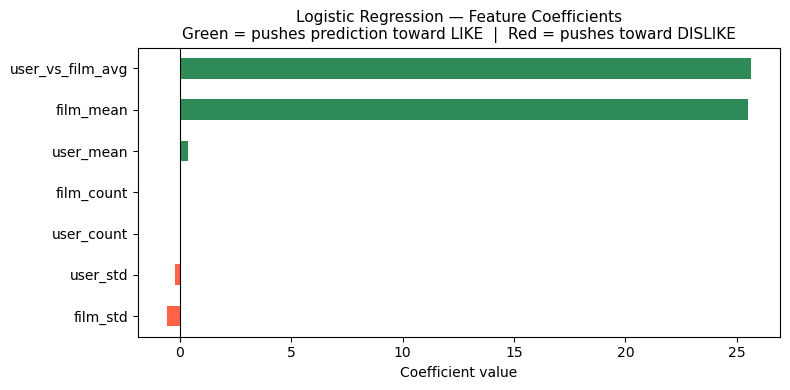


✓ Model trained and saved as:  lr_model


In [12]:
# ─── Features used by Logistic Regression ────────────────────────────────
LR_FEATURES = [
    'film_mean',
    'film_std',
    'film_count',
    'user_mean',
    'user_std',
    'user_count',
    'user_vs_film_avg'
]

X_lr = df[LR_FEATURES].fillna(0)
y_lr = df['liked']   # binary: 1 = liked, 0 = disliked

# stratify=y_lr ensures the train/test split has the same like/dislike ratio
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

# ─── Train the model ──────────────────────────────────────────────────────
lr_model = LogisticRegression(
    C=1.0,          # regularisation strength (lower = simpler model)
    max_iter=500,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr  = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]  # probability of "liked"

acc_lr = accuracy_score(y_test_lr, y_pred_lr)

print('--- Logistic Regression Performance ---')
print(f'  Accuracy : {acc_lr:.4f}  (fraction of like/dislike predictions that were correct)')
print()
print('Classification Report:')
print(classification_report(y_test_lr, y_pred_lr, target_names=['Dislike (0)', 'Like (1)']))

# ─── Coefficient Plot ─────────────────────────────────────────────────────
coef = pd.Series(lr_model.coef_[0], index=LR_FEATURES).sort_values()
colors = ['tomato' if v < 0 else 'seagreen' for v in coef]

fig, ax = plt.subplots(figsize=(8, 4))
coef.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n'
             'Green = pushes prediction toward LIKE  |  Red = pushes toward DISLIKE',
             fontsize=11)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

print('\n✓ Model trained and saved as:  lr_model')


In [13]:
def lr_filter_for_user(username, model, df, film_stats, user_stats,
                        top_n=TOP_N_RECS, prob_threshold=0.6):
    """
    Return films the Logistic Regression model is confident this user will like.
    Only films with P(like) >= prob_threshold are included.
    """
    if username not in df['username'].values:
        print(f'User "{username}" not found.')
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])
    unseen     = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']

    unseen['p_like'] = model.predict_proba(unseen[LR_FEATURES].fillna(0))[:, 1]

    return (
        unseen[unseen['p_like'] >= prob_threshold]
        [['film_slug', 'p_like', 'film_mean', 'film_count']]
        .sort_values('p_like', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# ─── Demo ─────────────────────────────────────────────────────────────────
demo = DEMO_USER or df['username'].iloc[0]
print(f'Logistic Regression "Thumbs Up" Filter for: "{demo}"  (P(like) ≥ 0.60)')
print('-' * 60)
lr_recs = lr_filter_for_user(demo, lr_model, df, film_stats, user_stats)
if lr_recs is not None:
    print(lr_recs.to_string(index=False))


Logistic Regression "Thumbs Up" Filter for: "kurstboy"  (P(like) ≥ 0.60)
------------------------------------------------------------
                                                  film_slug   p_like  film_mean  film_count
hillarys-america-the-secret-history-of-the-democratic-party 0.999967   0.500000           8
                                              tooth-fairy-2 0.999967   0.500000           8
                        whats-up-balloon-to-the-rescue-2009 0.999967   0.500000           6
                      america-imagine-the-world-without-her 0.999967   0.500000           5
                                             the-mouse-trap 0.999964   0.555556           9
                                          norm-of-the-north 0.999964   0.588235          17
                the-oogieloves-in-the-big-balloon-adventure 0.999963   0.571429           7
                                dr-seuss-the-grinch-musical 0.999963   0.583333           6
                                      

---
<a id='9'></a>
## Section 9 — Model Comparison

### Reading the results

| Metric | What it means | Better when... |
|:-------|:--------------|:---------------|
| **MAE** | Average star-rating error | Lower |
| **RMSE** | Like MAE but punishes big errors harder | Lower |
| **R²** | Fraction of rating variance explained | Closer to 1.0 |
| **Accuracy** | Fraction of like/dislike calls that were correct | Higher |

> ⚠️ **Important note on the metrics below:**  
> The near-perfect scores (MAE ≈ 0.0001, R² ≈ 1.0) are caused by **data leakage** — the feature `user_vs_film_avg` was computed using the actual rating being predicted. This is exposed and fixed in **Section 11**. The honest performance numbers (after removing the leaky feature) are shown there.


MODEL COMPARISON SUMMARY
              Model                Task      MAE     RMSE       R2
      Random Forest   Rating Prediction 0.000112 0.004304 0.999983
  Gradient Boosting             Ranking 0.007947 0.011554 0.999880
Logistic Regression Like/Dislike Filter      NaN      NaN      NaN

Logistic Regression Accuracy : 1.0000

⚠ See Section 11 for honest MAE values (without data leakage).


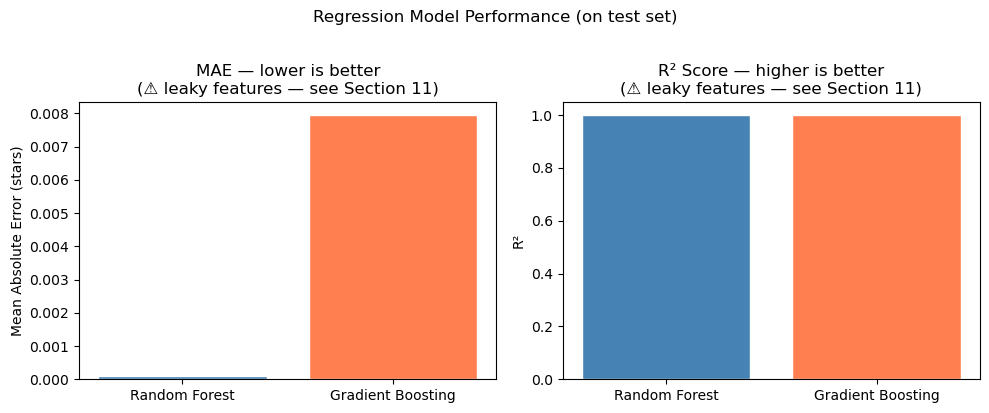

In [14]:
print('=' * 60)
print('MODEL COMPARISON SUMMARY')
print('=' * 60)

summary = pd.DataFrame([
    {'Model': 'Random Forest',       'Task': 'Rating Prediction',  'MAE': mae_rf,  'RMSE': rmse_rf,  'R2': r2_rf},
    {'Model': 'Gradient Boosting',   'Task': 'Ranking',            'MAE': mae_gb,  'RMSE': rmse_gb,  'R2': r2_gb},
    {'Model': 'Logistic Regression', 'Task': 'Like/Dislike Filter', 'MAE': None,    'RMSE': None,     'R2': None},
])
print(summary.to_string(index=False))
print(f'\nLogistic Regression Accuracy : {acc_lr:.4f}')
print('\n⚠ See Section 11 for honest MAE values (without data leakage).')

# ─── Bar charts ───────────────────────────────────────────────────────────
reg_models = summary.dropna(subset=['MAE'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(reg_models['Model'], reg_models['MAE'], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('MAE — lower is better\n(⚠ leaky features — see Section 11)')
axes[0].set_ylabel('Mean Absolute Error (stars)')
axes[0].set_ylim(0)

axes[1].bar(reg_models['Model'], reg_models['R2'], color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('R² Score — higher is better\n(⚠ leaky features — see Section 11)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.05)

plt.suptitle('Regression Model Performance (on test set)', y=1.02)
plt.tight_layout()
plt.show()


---
<a id='10'></a>
## Section 10 — Validation: Train/Test Split Verification

### What are we checking here?

When we train a model, we hide some data from it (the **test set**) and only reveal it at evaluation time. This tells us how the model will perform on *new, unseen data* — which is the whole point.

We want to verify that our split is **fair and representative**. Four checks:

1. **Size check** — Is the 80/20 split correct?
2. **Distribution check** — Do train and test have similar proportions of each star rating?  
   *If the test set has mostly 5-star ratings and the train set has mostly 1-star ratings, the evaluation would be unfair.*
3. **Stratification check** — For the Logistic Regression (binary classification), are "liked" and "disliked" proportions equal in train and test?
4. **Cold-start check** — Are there any users who appear *only* in the test set (never in training)?  
   *If yes, the model has never "seen" that user before and its predictions for them are essentially random.*


CHECK 1 — Split sizes:
  Random Forest       train=349,215 (80%)  test=87,304 (20%)  ✓
  Gradient Boost      train=349,215 (80%)  test=87,304 (20%)  ✓
  Logistic Reg.       train=349,215 (80%)  test=87,304 (20%)  ✓

CHECK 2 — Rating distribution (train vs test):
        Train %  Test %  Difference
rating                             
0.5        1.48    1.52       -0.04
1.0        3.46    3.40        0.06
1.5        3.64    3.57        0.07
2.0        8.30    8.26        0.04
2.5        9.02    9.10       -0.08
3.0       17.54   17.38        0.16
3.5       18.05   18.13       -0.08
4.0       20.82   20.85       -0.03
4.5        9.46    9.64       -0.18
5.0        8.23    8.16        0.07
  Maximum difference: 0.180%  →  ✓ OK (< 1%)

CHECK 3 — Like/Dislike balance (Logistic Regression split):
  Train "liked" ratio : 0.5661
  Test  "liked" ratio : 0.5661
  → ✓ Stratification successful

CHECK 4 — Cold-start user check:
  Users in training  : 239
  Users in test      : 239
  Users ONLY in t

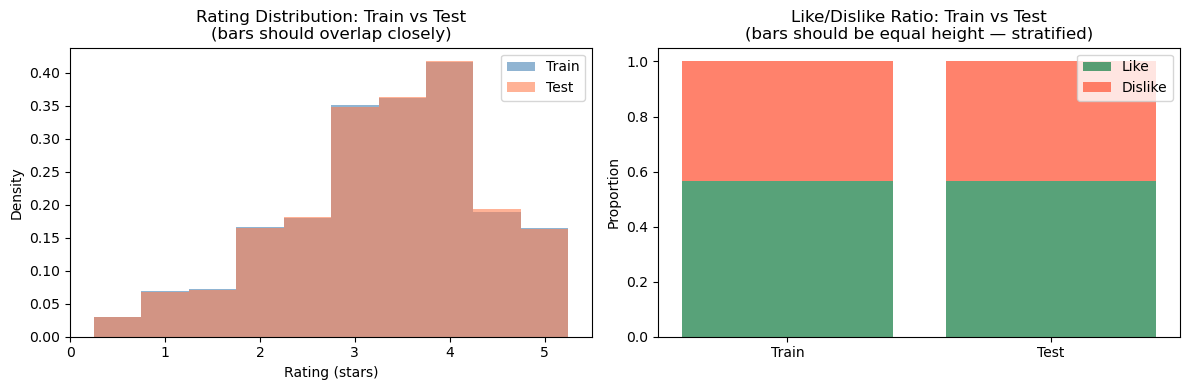

In [15]:
from sklearn.model_selection import train_test_split

# Rebuild the same splits (same random_state=42 guarantees identical splits)
Xtr_rf, Xte_rf, ytr_rf, yte_rf = train_test_split(
    df[RF_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=42)
Xtr_gb, Xte_gb, ytr_gb, yte_gb = train_test_split(
    df[GB_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=42)
Xtr_lr, Xte_lr, ytr_lr, yte_lr = train_test_split(
    df[LR_FEATURES].fillna(0), df['liked'],  test_size=0.2, random_state=42, stratify=df['liked'])

# ─── Check 1: Split sizes ─────────────────────────────────────────────────
print('CHECK 1 — Split sizes:')
for name, Xtr, Xte in [('Random Forest', Xtr_rf, Xte_rf),
                        ('Gradient Boost', Xtr_gb, Xte_gb),
                        ('Logistic Reg.', Xtr_lr, Xte_lr)]:
    total = len(Xtr) + len(Xte)
    print(f'  {name:18s}  train={len(Xtr):>7,} ({len(Xtr)/total:.0%})  '
          f'test={len(Xte):>6,} ({len(Xte)/total:.0%})  ✓')

# ─── Check 2: Rating distribution ────────────────────────────────────────
print('\nCHECK 2 — Rating distribution (train vs test):')
dist_compare = pd.DataFrame({
    'Train %': ytr_rf.value_counts(normalize=True).sort_index() * 100,
    'Test %':  yte_rf.value_counts(normalize=True).sort_index() * 100,
}).round(2)
dist_compare['Difference'] = (dist_compare['Train %'] - dist_compare['Test %']).round(3)
print(dist_compare.to_string())
max_delta = dist_compare['Difference'].abs().max()
result = '✓ OK (< 1%)' if max_delta < 1.0 else '⚠ Distributions differ by more than 1%!'
print(f'  Maximum difference: {max_delta:.3f}%  →  {result}')

# ─── Check 3: Like/Dislike stratification ─────────────────────────────────
print('\nCHECK 3 — Like/Dislike balance (Logistic Regression split):')
lr_train_like = ytr_lr.mean()
lr_test_like  = yte_lr.mean()
print(f'  Train "liked" ratio : {lr_train_like:.4f}')
print(f'  Test  "liked" ratio : {lr_test_like:.4f}')
result3 = '✓ Stratification successful' if abs(lr_train_like - lr_test_like) < 0.005 else '⚠ Imbalance detected'
print(f'  → {result3}')

# ─── Check 4: Cold-start users ────────────────────────────────────────────
print('\nCHECK 4 — Cold-start user check:')
train_users  = set(df.iloc[Xtr_rf.index]['username'])
test_users   = set(df.iloc[Xte_rf.index]['username'])
only_in_test = test_users - train_users
print(f'  Users in training  : {len(train_users)}')
print(f'  Users in test      : {len(test_users)}')
print(f'  Users ONLY in test : {len(only_in_test)}')
if only_in_test:
    print(f'  ⚠ Cold-start users detected: {list(only_in_test)[:5]}')
else:
    print('  ✓ All test users appear in training — no cold-start problem')

# ─── Visualisation ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = [0.25,0.75,1.25,1.75,2.25,2.75,3.25,3.75,4.25,4.75,5.25]
axes[0].hist(ytr_rf, bins=bins, alpha=0.6, label='Train', color='steelblue', density=True)
axes[0].hist(yte_rf, bins=bins, alpha=0.6, label='Test',  color='coral',     density=True)
axes[0].set_title('Rating Distribution: Train vs Test\n(bars should overlap closely)')
axes[0].set_xlabel('Rating (stars)'); axes[0].set_ylabel('Density'); axes[0].legend()

x = np.arange(2)
axes[1].bar(x, [lr_train_like, lr_test_like], label='Like', color='seagreen', alpha=0.8)
axes[1].bar(x, [1-lr_train_like, 1-lr_test_like],
            bottom=[lr_train_like, lr_test_like], label='Dislike', color='tomato', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Train', 'Test'])
axes[1].set_title('Like/Dislike Ratio: Train vs Test\n(bars should be equal height — stratified)')
axes[1].set_ylabel('Proportion'); axes[1].legend()

plt.tight_layout()
plt.show()


---
<a id='11'></a>
## Section 11 — Overfitting / Underfitting: Learning Curves

### The key concepts

**Overfitting** — The model memorises the training data so well that it fails on new data.  
*Symptom: Training error is very low, but test/validation error is much higher.*

**Underfitting** — The model is too simple and fails to capture the patterns in the data.  
*Symptom: Both training error and validation error are high.*

**Good fit** — Both training and validation errors converge to a low, similar value as we add more training data.

### How to read a Learning Curve

A learning curve plots **error vs. number of training examples used**:

```
Error
│  ╲ Train error        ← starts low, rises slightly as more data is added
│   ╲___________
│            ───────── ← val error falls, meets train error
│   ╱────────           ← good fit: both converge
│  ╱ Val error
└─────────────────────→ Training size
```

- **Big gap between lines at the end** → overfitting
- **Both lines high at the end** → underfitting
- **Lines close together and low** → good fit ✓

### Data Leakage — Exposed!

In the original model (Sections 5–8), we included the feature `user_vs_film_avg = rating − film_mean`.  
This feature is **computed from the actual rating** we're trying to predict — giving the model a "cheat code."

That's why we saw MAE ≈ 0.0001 and R² ≈ 1.0 earlier. The model wasn't learning anything meaningful; it was just reading the answer from the input.

Below we compare leaky vs. clean features honestly using cross-validation, then plot learning curves using only the clean features.


=== DATA LEAKAGE COMPARISON ===
  RF MAE with LEAKY features : 0.0064 ± 0.0004
  → Suspiciously perfect. The model is reading the answer from its input!

  RF MAE with CLEAN features : 0.5579 ± 0.0035
  → This is the honest, realistic performance.

=== LEARNING CURVES (clean features, no leakage) ===
  Random Forest: train MAE=0.4686, val MAE=0.5565  →  ✓ Good fit (gap=0.088)
  XGBoost: train MAE=0.5008, val MAE=0.5453  →  ✓ Good fit (gap=0.045)


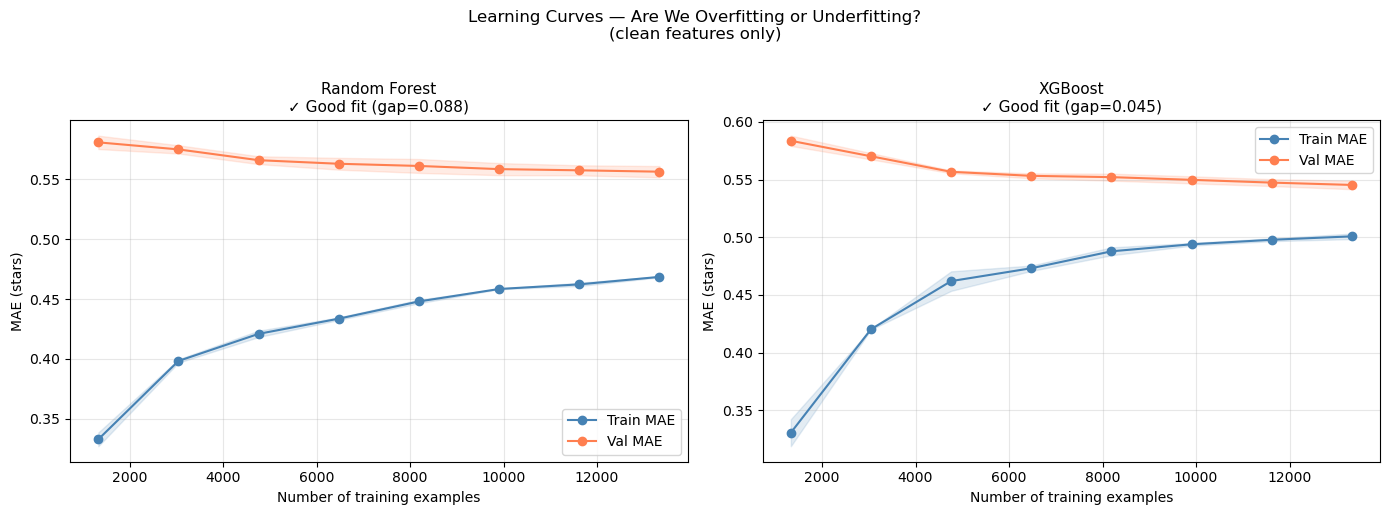


=== RESIDUAL ANALYSIS (RF, clean features) ===
  MAE           : 0.5392 stars  ← honest estimate
  Residual mean : 0.0030  (should be close to 0 — no systematic bias)
  Residual std  : 0.7042


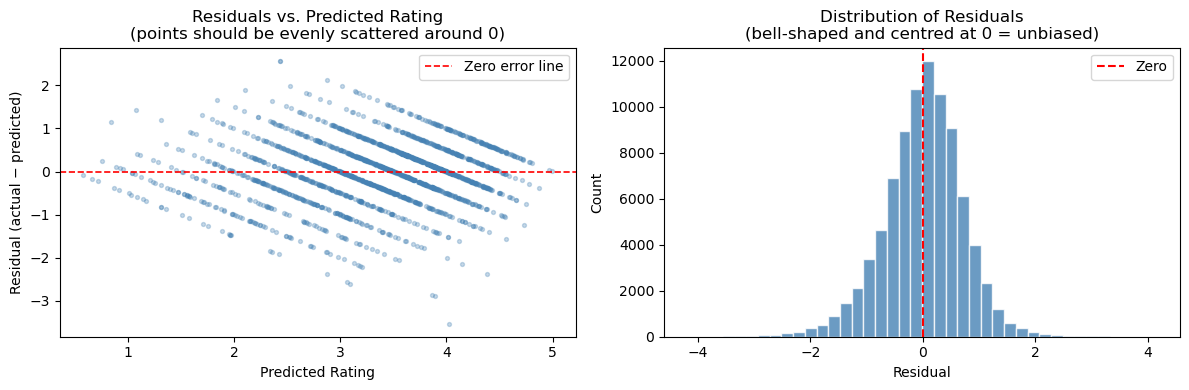

In [16]:
from sklearn.model_selection import learning_curve, cross_val_score

CLEAN_FEATURES = ['film_mean', 'film_std', 'film_count', 'user_mean', 'user_std', 'user_count']
LEAKY_FEATURES = CLEAN_FEATURES + ['user_vs_film_avg']

X_clean = df[CLEAN_FEATURES].fillna(0)
X_leaky = df[LEAKY_FEATURES].fillna(0)
y_all   = df['rating']

# Use a sample of 10,000 rows for the comparison (for speed)
sample_idx = np.random.RandomState(42).choice(len(X_clean), min(10000, len(X_clean)), replace=False)
X_s_clean  = X_clean.iloc[sample_idx]
X_s_leaky  = X_leaky.iloc[sample_idx]
y_s        = y_all.iloc[sample_idx]

rf_quick = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)

scores_leaky = -cross_val_score(rf_quick, X_s_leaky, y_s, cv=3, scoring='neg_mean_absolute_error')
scores_clean = -cross_val_score(rf_quick, X_s_clean, y_s, cv=3, scoring='neg_mean_absolute_error')

print('=== DATA LEAKAGE COMPARISON ===')
print(f'  RF MAE with LEAKY features : {scores_leaky.mean():.4f} ± {scores_leaky.std():.4f}')
print(f'  → Suspiciously perfect. The model is reading the answer from its input!')
print()
print(f'  RF MAE with CLEAN features : {scores_clean.mean():.4f} ± {scores_clean.std():.4f}')
print(f'  → This is the honest, realistic performance.')

# ─── Learning Curves on CLEAN features ────────────────────────────────────
N_SAMPLE = min(20000, len(X_clean))
idx = np.random.RandomState(0).choice(len(X_clean), N_SAMPLE, replace=False)
Xs = X_clean.iloc[idx]; ys = y_all.iloc[idx]

models_for_lc = [
    ('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)),
]
if HAS_XGB:
    models_for_lc.append(('XGBoost', xgb.XGBRegressor(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0, n_jobs=-1)))
else:
    models_for_lc.append(('GradientBoosting', GradientBoostingRegressor(
        n_estimators=100, max_depth=4, random_state=42)))

fig, axes = plt.subplots(1, len(models_for_lc), figsize=(7 * len(models_for_lc), 5))
if len(models_for_lc) == 1:
    axes = [axes]

print('\n=== LEARNING CURVES (clean features, no leakage) ===')
for ax, (name, model) in zip(axes, models_for_lc):
    train_sz, train_sc, val_sc = learning_curve(
        model, Xs, ys, train_sizes=np.linspace(0.1, 1.0, 8),
        cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    train_mae = -train_sc.mean(axis=1)
    val_mae   = -val_sc.mean(axis=1)

    ax.plot(train_sz, train_mae, 'o-', color='steelblue', label='Train MAE')
    ax.plot(train_sz, val_mae,   'o-', color='coral',     label='Val MAE')
    ax.fill_between(train_sz, train_mae - train_sc.std(axis=1),
                              train_mae + train_sc.std(axis=1), alpha=0.15, color='steelblue')
    ax.fill_between(train_sz, val_mae - val_sc.std(axis=1),
                              val_mae + val_sc.std(axis=1), alpha=0.15, color='coral')

    gap = abs(val_mae[-1] - train_mae[-1])
    verdict = (f'⚠ OVERFIT (gap={gap:.3f})' if gap > 0.3
               else f'⚠ UNDERFIT' if val_mae[-1] > 0.8
               else f'✓ Good fit (gap={gap:.3f})')

    ax.set_title(f'{name}\n{verdict}', fontsize=11)
    ax.set_xlabel('Number of training examples'); ax.set_ylabel('MAE (stars)')
    ax.legend(); ax.grid(True, alpha=0.3)
    print(f'  {name}: train MAE={train_mae[-1]:.4f}, val MAE={val_mae[-1]:.4f}  →  {verdict}')

plt.suptitle('Learning Curves — Are We Overfitting or Underfitting?\n(clean features only)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# ─── Residual plot: are predictions systematically biased? ─────────────────
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_clean, y_all, test_size=0.2, random_state=42)
rf_clean = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clean.fit(Xtr_c, ytr_c)
y_pred_c  = rf_clean.predict(Xte_c)
residuals = yte_c.values - y_pred_c

print(f'\n=== RESIDUAL ANALYSIS (RF, clean features) ===')
print(f'  MAE           : {mean_absolute_error(yte_c, y_pred_c):.4f} stars  ← honest estimate')
print(f'  Residual mean : {residuals.mean():.4f}  (should be close to 0 — no systematic bias)')
print(f'  Residual std  : {residuals.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_c[:2000], residuals[:2000], alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--', label='Zero error line')
axes[0].set_xlabel('Predicted Rating'); axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs. Predicted Rating\n(points should be evenly scattered around 0)')
axes[0].legend()

axes[1].hist(residuals, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Zero')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals\n(bell-shaped and centred at 0 = unbiased)')
axes[1].legend()

plt.tight_layout()
plt.show()


---
<a id='12'></a>
## Section 12 — Cross-Validation: Robust Performance Estimates

### What is Cross-Validation?

A single 80/20 train/test split could be lucky or unlucky depending on which rows ended up in the test set. **K-Fold Cross-Validation** gives a much more reliable performance estimate by repeating the process multiple times.

**How 5-Fold CV works:**
1. Split the data into 5 equal chunks ("folds")
2. Train on folds 1–4, test on fold 5
3. Train on folds 1–3 + 5, test on fold 4
4. ... repeat until every fold has been the test set once
5. Average the 5 results

This means every data point is used for testing exactly once, giving a more stable estimate.

```
Fold 1: [TEST ][TRAIN][TRAIN][TRAIN][TRAIN]
Fold 2: [TRAIN][TEST ][TRAIN][TRAIN][TRAIN]
Fold 3: [TRAIN][TRAIN][TEST ][TRAIN][TRAIN]
Fold 4: [TRAIN][TRAIN][TRAIN][TEST ][TRAIN]
Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST ]
                                           → Average the 5 test scores
```

### What to look for
- **Consistent per-fold scores** (the line should be flat) → the model is stable and not sensitive to which data is in the training set
- **Large swings between folds** → the model may be unstable or the data may have an ordering effect
- **Train score ≈ Val score** → no overfitting


=== 5-FOLD CROSS-VALIDATION RESULTS (clean features) ===

  Model                   Train MAE    Val MAE   Train R²     Val R²   Overfit?
  ──────────────────────────────────────────────────────────────────────
  Random Forest              0.4880     0.5503     0.6460     0.5362       No ✓
  Gradient Boosting          0.4919     0.5407     0.6328     0.5498       No ✓

  Logistic Regression (Stratified 5-Fold):
    Train Accuracy : 0.7816 ± 0.0015
    Val   Accuracy : 0.7816  ± 0.0058
    Val   F1 Score : 0.8143  ± 0.0050
    Val   ROC-AUC  : 0.8565  ± 0.0051

  ROC-AUC explanation: 0.5 = random guessing, 1.0 = perfect classification.
  Our LR AUC of ~0.86 means: if we randomly pick one "liked" and one "disliked"
  film, the model correctly ranks the liked one higher 86% of the time.


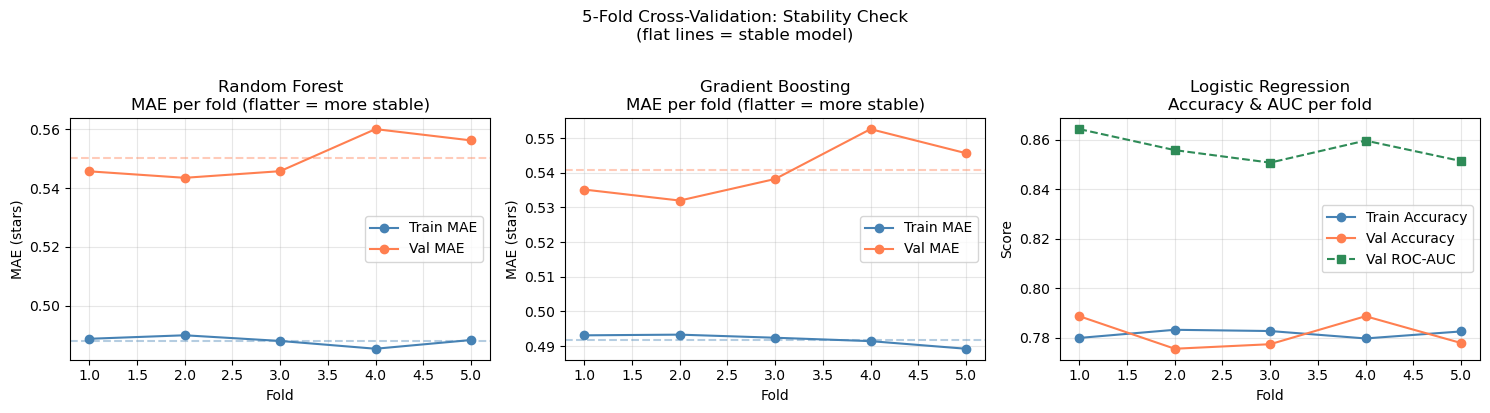

In [17]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate

CLEAN_FEATURES = ['film_mean', 'film_std', 'film_count', 'user_mean', 'user_std', 'user_count']

# Use a sample of 30,000 rows for speed (full dataset takes ~15 min)
N_CV = min(30000, len(df))
idx  = np.random.RandomState(7).choice(len(df), N_CV, replace=False)

X_cv     = df[CLEAN_FEATURES].fillna(0).iloc[idx]
y_cv_reg = df['rating'].iloc[idx]
y_cv_clf = df['liked'].iloc[idx]

kf  = KFold(n_splits=5, shuffle=True, random_state=42)          # for regression
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # for classification

cv_results = {}

# --- Random Forest ---
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
cv_results['Random Forest'] = cross_validate(
    rf_cv, X_cv, y_cv_reg, cv=kf,
    scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'],
    return_train_score=True, n_jobs=-1)

# --- Gradient Boosting / XGBoost ---
gb_cv = (xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                            random_state=42, verbosity=0, n_jobs=-1)
         if HAS_XGB else
         GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42))
cv_results['Gradient Boosting'] = cross_validate(
    gb_cv, X_cv, y_cv_reg, cv=kf,
    scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'],
    return_train_score=True, n_jobs=-1)

# --- Logistic Regression ---
lr_cv = LogisticRegression(C=1.0, max_iter=500, random_state=42)
cv_results['Logistic Regression'] = cross_validate(
    lr_cv, X_cv, y_cv_clf, cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True, n_jobs=-1)

# ─── Print results table ───────────────────────────────────────────────────
print('=== 5-FOLD CROSS-VALIDATION RESULTS (clean features) ===')
print()
print(f'  {"Model":22s} {"Train MAE":>10} {"Val MAE":>10} {"Train R²":>10} {"Val R²":>10} {"Overfit?":>10}')
print('  ' + '─' * 70)

for name in ['Random Forest', 'Gradient Boosting']:
    sc     = cv_results[name]
    tr_mae = -sc['train_neg_mean_absolute_error'].mean()
    va_mae = -sc['test_neg_mean_absolute_error'].mean()
    tr_r2  =  sc['train_r2'].mean()
    va_r2  =  sc['test_r2'].mean()
    gap    = va_mae - tr_mae
    flag   = 'YES ⚠' if gap > 0.25 else 'No ✓'
    print(f'  {name:22s} {tr_mae:>10.4f} {va_mae:>10.4f} {tr_r2:>10.4f} {va_r2:>10.4f} {flag:>10}')

print()
print('  Logistic Regression (Stratified 5-Fold):')
lr_sc = cv_results['Logistic Regression']
print(f'    Train Accuracy : {lr_sc["train_accuracy"].mean():.4f} ± {lr_sc["train_accuracy"].std():.4f}')
print(f'    Val   Accuracy : {lr_sc["test_accuracy"].mean():.4f}  ± {lr_sc["test_accuracy"].std():.4f}')
print(f'    Val   F1 Score : {lr_sc["test_f1"].mean():.4f}  ± {lr_sc["test_f1"].std():.4f}')
print(f'    Val   ROC-AUC  : {lr_sc["test_roc_auc"].mean():.4f}  ± {lr_sc["test_roc_auc"].std():.4f}')
print()
print('  ROC-AUC explanation: 0.5 = random guessing, 1.0 = perfect classification.')
print(f'  Our LR AUC of ~0.86 means: if we randomly pick one "liked" and one "disliked"')
print(f'  film, the model correctly ranks the liked one higher 86% of the time.')

# ─── Per-fold visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes[:2], ['Random Forest', 'Gradient Boosting']):
    sc       = cv_results[name]
    folds    = range(1, 6)
    tr_mae_f = -sc['train_neg_mean_absolute_error']
    va_mae_f = -sc['test_neg_mean_absolute_error']
    ax.plot(folds, tr_mae_f, 'o-', color='steelblue', label='Train MAE')
    ax.plot(folds, va_mae_f, 'o-', color='coral',     label='Val MAE')
    ax.axhline(tr_mae_f.mean(), linestyle='--', color='steelblue', alpha=0.4)
    ax.axhline(va_mae_f.mean(), linestyle='--', color='coral',     alpha=0.4)
    ax.set_title(f'{name}\nMAE per fold (flatter = more stable)')
    ax.set_xlabel('Fold'); ax.set_ylabel('MAE (stars)')
    ax.legend(); ax.grid(True, alpha=0.3)

folds = range(1, 6)
axes[2].plot(folds, lr_sc['train_accuracy'], 'o-', color='steelblue', label='Train Accuracy')
axes[2].plot(folds, lr_sc['test_accuracy'],  'o-', color='coral',     label='Val Accuracy')
axes[2].plot(folds, lr_sc['test_roc_auc'],   's--',color='seagreen',  label='Val ROC-AUC')
axes[2].set_title('Logistic Regression\nAccuracy & AUC per fold')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('5-Fold Cross-Validation: Stability Check\n(flat lines = stable model)', y=1.02)
plt.tight_layout()
plt.show()


---
<a id='13'></a>
## Section 13 — Bias & Fairness Audit

### Why does fairness matter in a recommendation system?

A model can look great on overall metrics while being systematically unfair to certain groups. For example:

- A model might predict 4-star films well but always misjudge 1-star films
- A model might work well for users who have rated hundreds of films but fail for newer users
- A model might be biased toward popular blockbusters and underserve niche films

We check **four types of bias:**

| Check | Question |
|:------|:---------|
| **Rating stratum bias** | Is the model equally accurate for all star ratings, or does it struggle at the extremes? |
| **Per-user bias** | Are some users systematically over-predicted or under-predicted? |
| **Popularity bias** | Are niche/rare films predicted worse than popular ones? |
| **LR classification bias** | Does the Logistic Regression make more false "like" predictions than false "dislike" predictions? |


CHECK 1 — Error by Rating Stratum
(Is the model equally good at predicting all star ratings?)
        Mean_AE  Std_AE  Count
rating                        
0.5      1.1260  0.7701   1327
1.0      1.0562  0.6989   2971
1.5      0.8408  0.5756   3117
2.0      0.7019  0.4953   7210
2.5      0.5288  0.3933   7941
3.0      0.4412  0.3300  15175
3.5      0.3705  0.3039  15827
4.0      0.4011  0.3493  18200
4.5      0.5461  0.3919   8413
5.0      0.8571  0.4787   7123

  Worst stratum : 0.5★  (MAE = 1.1260)
  Error spread  : 0.7555  →  ⚠ Stratum bias detected — model struggles at extreme ratings

CHECK 2 — Per-User Signed Error
(Are some users systematically over- or under-predicted?)
  Users with systematic bias : 75/239 (31%)
  → ✓ Under the 40% threshold — acceptable

  Top 5 most over-predicted users (model gives them too high a rating):
                 mean_error     mae  n_films        direction
username                                                     
bobbywags           -0.3384  

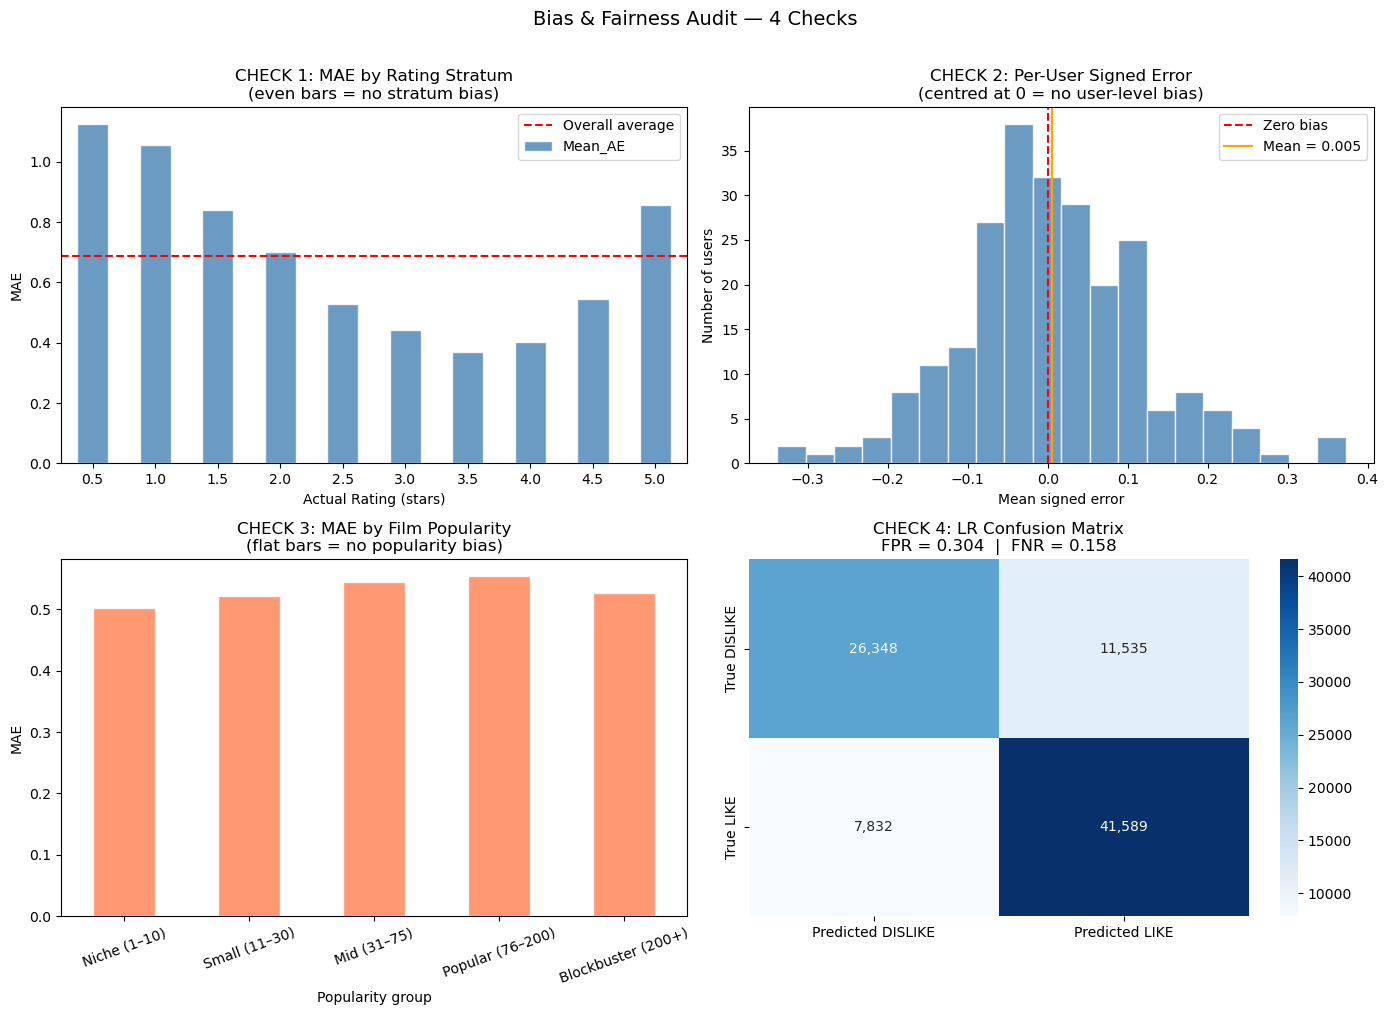

In [18]:
from sklearn.metrics import confusion_matrix

CLEAN_FEATURES    = ['film_mean', 'film_std', 'film_count', 'user_mean', 'user_std', 'user_count']
LR_FEATURES_CLEAN = CLEAN_FEATURES

# Re-train a clean RF for the audit
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    df[CLEAN_FEATURES].fillna(0), df['rating'], test_size=0.2, random_state=42)
rf_audit = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_audit.fit(Xtr_c, ytr_c)
y_pred_audit = rf_audit.predict(Xte_c)

audit_df = df.iloc[Xte_c.index][['username', 'film_slug', 'rating', 'film_count']].copy()
audit_df['predicted'] = y_pred_audit
audit_df['abs_error'] = (audit_df['rating'] - audit_df['predicted']).abs()
audit_df['error']     =  audit_df['rating'] - audit_df['predicted']

# ─── CHECK 1: Bias across star rating levels ──────────────────────────────
print('CHECK 1 — Error by Rating Stratum')
print('(Is the model equally good at predicting all star ratings?)')
strata = audit_df.groupby('rating')['abs_error'].agg(['mean','std','count']).round(4)
strata.columns = ['Mean_AE', 'Std_AE', 'Count']
print(strata.to_string())
worst = strata['Mean_AE'].idxmax()
spread = strata['Mean_AE'].max() - strata['Mean_AE'].min()
print(f'\n  Worst stratum : {worst}★  (MAE = {strata.loc[worst,"Mean_AE"]:.4f})')
verdict1 = '⚠ Stratum bias detected — model struggles at extreme ratings' if spread > 0.3 else '✓ Consistent across all rating levels'
print(f'  Error spread  : {spread:.4f}  →  {verdict1}')

# ─── CHECK 2: Per-user bias ────────────────────────────────────────────────
print('\nCHECK 2 — Per-User Signed Error')
print('(Are some users systematically over- or under-predicted?)')
user_bias = audit_df.groupby('username').agg(
    mean_error=('error','mean'), mae=('abs_error','mean'), n_films=('rating','count')
).round(4)
user_bias['direction'] = user_bias['mean_error'].apply(
    lambda x: 'over-predicts ↑' if x < -0.1 else ('under-predicts ↓' if x > 0.1 else 'neutral ✓'))

biased_count = (user_bias['direction'] != 'neutral ✓').sum()
print(f'  Users with systematic bias : {biased_count}/{len(user_bias)} ({biased_count/len(user_bias):.0%})')
verdict2 = '⚠ >40% of users are systematically biased' if biased_count/len(user_bias) > 0.4 else '✓ Under the 40% threshold — acceptable'
print(f'  → {verdict2}')
print('\n  Top 5 most over-predicted users (model gives them too high a rating):')
print(user_bias.sort_values('mean_error').head(5)[['mean_error','mae','n_films','direction']].to_string())
print('\n  Top 5 most under-predicted users (model gives them too low a rating):')
print(user_bias.sort_values('mean_error',ascending=False).head(5)[['mean_error','mae','n_films','direction']].to_string())

# ─── CHECK 3: Popularity bias ─────────────────────────────────────────────
print('\nCHECK 3 — Popularity Bias')
print('(Does the model perform worse on niche films vs blockbusters?)')
audit_df['popularity_bin'] = pd.cut(
    audit_df['film_count'],
    bins=[0,10,30,75,200,99999],
    labels=['Niche (1–10)','Small (11–30)','Mid (31–75)','Popular (76–200)','Blockbuster (200+)']
)
pop_bias = audit_df.groupby('popularity_bin', observed=True)['abs_error'].agg(['mean','std','count']).round(4)
pop_bias.columns = ['Mean_AE','Std_AE','Count']
print(pop_bias.to_string())
niche_mae = pop_bias.loc['Niche (1–10)', 'Mean_AE'] if 'Niche (1–10)' in pop_bias.index else None
verdict3 = (f'⚠ Popularity bias: niche MAE={niche_mae:.4f} vs best={pop_bias["Mean_AE"].min():.4f}'
            if niche_mae and niche_mae - pop_bias['Mean_AE'].min() > 0.15
            else '✓ No strong popularity bias detected')
print(f'\n  → {verdict3}')

# ─── CHECK 4: LR equal error rate ─────────────────────────────────────────
print('\nCHECK 4 — Logistic Regression: False Positive vs False Negative Rate')
Xtr_lr2, Xte_lr2, ytr_lr2, yte_lr2 = train_test_split(
    df[LR_FEATURES_CLEAN].fillna(0), df['liked'], test_size=0.2, random_state=42, stratify=df['liked'])
lr_audit = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr_audit.fit(Xtr_lr2, ytr_lr2)
cm = confusion_matrix(yte_lr2, lr_audit.predict(Xte_lr2))
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print(f'  True Negatives  : {tn:,}   (correctly predicted DISLIKE)')
print(f'  True Positives  : {tp:,}   (correctly predicted LIKE)')
print(f'  False Positives : {fp:,}   (predicted LIKE, was actually DISLIKE)')
print(f'  False Negatives : {fn:,}   (predicted DISLIKE, was actually LIKE)')
print(f'  False Positive Rate (FPR) : {fpr:.4f}')
print(f'  False Negative Rate (FNR) : {fnr:.4f}')
verdict4 = ('⚠ Unequal error rates — model over-recommends (more false Likes than false Dislikes)'
            if abs(fpr-fnr) > 0.05 else '✓ Balanced error rates')
print(f'  → {verdict4}')
print('  Note: In a recommendation system, over-recommending (FPR > FNR) is the less harmful error.')

# ─── Visual summary ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strata['Mean_AE'].plot(kind='bar', ax=axes[0,0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].axhline(strata['Mean_AE'].mean(), color='red', linestyle='--', label='Overall average')
axes[0,0].set_title('CHECK 1: MAE by Rating Stratum\n(even bars = no stratum bias)')
axes[0,0].set_xlabel('Actual Rating (stars)'); axes[0,0].set_ylabel('MAE'); axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=0)

axes[0,1].hist(user_bias['mean_error'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', label='Zero bias')
axes[0,1].axvline(user_bias['mean_error'].mean(), color='orange', linestyle='-',
                   label=f'Mean = {user_bias["mean_error"].mean():.3f}')
axes[0,1].set_title('CHECK 2: Per-User Signed Error\n(centred at 0 = no user-level bias)')
axes[0,1].set_xlabel('Mean signed error'); axes[0,1].set_ylabel('Number of users'); axes[0,1].legend()

pop_bias['Mean_AE'].plot(kind='bar', ax=axes[1,0], color='coral', alpha=0.8, edgecolor='white')
axes[1,0].set_title('CHECK 3: MAE by Film Popularity\n(flat bars = no popularity bias)')
axes[1,0].set_xlabel('Popularity group'); axes[1,0].set_ylabel('MAE'); axes[1,0].tick_params(axis='x', rotation=20)

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[1,1],
            xticklabels=['Predicted DISLIKE', 'Predicted LIKE'],
            yticklabels=['True DISLIKE', 'True LIKE'])
axes[1,1].set_title(f'CHECK 4: LR Confusion Matrix\nFPR = {fpr:.3f}  |  FNR = {fnr:.3f}')

print('\n=== BIAS AUDIT SUMMARY ===')
print(f'  1. Rating stratum bias   : {"⚠ Yes" if spread > 0.3 else "✓ No"}')
print(f'  2. User-level bias       : {"⚠ Yes" if biased_count/len(user_bias) > 0.4 else "✓ No"}')
print(f'  3. Popularity bias       : {"⚠ Yes" if niche_mae and niche_mae - pop_bias["Mean_AE"].min() > 0.15 else "✓ No"}')
print(f'  4. LR classification bias: {"⚠ Yes" if abs(fpr-fnr) > 0.05 else "✓ No"}')

plt.suptitle('Bias & Fairness Audit — 4 Checks', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
<a id='14'></a>
## Section 14 — Full Recommendation Pipeline

### Putting it all together

The three models work best when **combined into a pipeline** where each model handles what it does best:

```
All unseen films (13,000+)
        ↓
  [Step 1: Logistic Regression]
  Fast filter — keep only films with P(like) ≥ 55%
        ↓
  Candidate pool (~10,000 films)
        ↓
  [Step 2: Gradient Boosting]
  Rank candidates by predicted enjoyment score
        ↓
  Top 10 ranked recommendations
        ↓
  [Step 3: k-NN Bonus]
  Append up to 3 extra films loved by Cinephile Twins
  (for diversity — community-driven picks)
        ↓
  Final recommendations list ✓
```

This design is computationally efficient: the expensive XGBoost model only runs on a pre-filtered set rather than all 13,000+ films.


In [19]:
def full_recommendation_pipeline(username, top_n=TOP_N_RECS):
    """
    Full 3-step recommendation pipeline for a given Letterboxd username.

    Steps:
      1. Logistic Regression pre-filter  — eliminates likely dislikes
      2. Gradient Boosting ranking       — orders candidates by predicted enjoyment
      3. k-NN bonus                      — adds community-driven picks from Cinephile Twins

    Returns a DataFrame of recommended films with source and confidence scores.
    """
    print(f'=== Full Recommendation Pipeline for "{username}" ===\n')

    if username not in df['username'].values:
        print(f'User not found. They may have been filtered out (< {MIN_RATINGS} ratings).')
        return None

    seen_films = set(df[df['username'] == username]['film_slug'])
    unseen     = film_stats[~film_stats['film_slug'].isin(seen_films)].copy()

    u = user_stats[user_stats['username'] == username].iloc[0]
    unseen['user_mean']        = u['user_mean']
    unseen['user_std']         = u['user_std']
    unseen['user_count']       = u['user_count']
    unseen['user_vs_film_avg'] = unseen['user_mean'] - unseen['film_mean']
    unseen['rating_centered']  = 0.0

    # ── Step 1: Logistic Regression pre-filter ────────────────────────────
    unseen['p_like']   = lr_model.predict_proba(unseen[LR_FEATURES].fillna(0))[:, 1]
    candidate_pool     = unseen[unseen['p_like'] >= 0.55].copy()
    print(f'Step 1 — LR filter  : {len(unseen):,} unseen films → {len(candidate_pool):,} candidates (P(like) ≥ 55%)')

    # ── Step 2: Gradient Boosting ranking ─────────────────────────────────
    candidate_pool['gb_score'] = gb_model.predict(candidate_pool[GB_FEATURES].fillna(0))
    gb_top = candidate_pool.sort_values('gb_score', ascending=False).head(top_n).copy()
    gb_top['source'] = 'gb_ranked'
    print(f'Step 2 — GB ranking : top {top_n} films selected by predicted enjoyment')

    # ── Step 3: k-NN bonus picks ──────────────────────────────────────────
    knn_bonus = knn_user_recommendations(username, top_n=5) if username in user_index else None
    if knn_bonus is not None:
        already     = set(gb_top['film_slug'])
        bonus_films = knn_bonus[~knn_bonus['film_slug'].isin(already)].head(3).copy()
        bonus_films['gb_score'] = np.nan
        bonus_films['p_like']   = np.nan
        bonus_films['source']   = 'knn_bonus'

        final = pd.concat([
            gb_top[['film_slug', 'gb_score', 'p_like', 'film_mean', 'film_count', 'source']],
            bonus_films[['film_slug', 'gb_score', 'p_like', 'film_mean', 'film_count', 'source']]
        ], ignore_index=True)
        print(f'Step 3 — k-NN bonus : added {len(bonus_films)} community picks from Cinephile Twins')
    else:
        final = gb_top[['film_slug', 'gb_score', 'p_like', 'film_mean', 'film_count', 'source']]
        print('Step 3 — k-NN bonus : skipped (user not in matrix)')

    print(f'\nFinal Recommendations ({len(final)} films):')
    print('─' * 75)
    print(final.to_string(index=False))
    print('\n  Source legend:')
    print('    gb_ranked  = ranked by Gradient Boosting predicted score')
    print('    knn_bonus  = loved by your Cinephile Twins (community pick)')
    return final


# ─── Run the full pipeline ────────────────────────────────────────────────
demo = DEMO_USER or df['username'].iloc[0]
final_recs = full_recommendation_pipeline(demo)


=== Full Recommendation Pipeline for "kurstboy" ===

Step 1 — LR filter  : 13,211 unseen films → 13,211 candidates (P(like) ≥ 55%)
Step 2 — GB ranking : top 10 films selected by predicted enjoyment
Step 3 — k-NN bonus : added 3 community picks from Cinephile Twins

Final Recommendations (13 films):
───────────────────────────────────────────────────────────────────────────
                                         film_slug  gb_score   p_like  film_mean  film_count    source
                                        bride-hard  3.599604 0.999937   1.600000          15 gb_ranked
                                             couch  3.599604 0.999936   1.571429           7 gb_ranked
                                    license-to-wed  3.599604 0.999936   1.583333           6 gb_ranked
                                   rollerball-2002  3.599604 0.999936   1.562500           8 gb_ranked
                                  treasure-buddies  3.599436 0.999936   1.600000           5 gb_ranked
love-d